In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# uv add langchain_community pymupdf
from langchain_community.document_loaders import PyMuPDFLoader

# 문서 로드
loader = PyMuPDFLoader(r"..\data\Employee_Benefits_Guide_2026_v1.pdf")
documents = loader.load()

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 문서 분할
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
splitted_documents = text_splitter.split_documents(documents)

In [10]:
# uv add langchain_ollama
from langchain_ollama import OllamaEmbeddings

embedding_model = OllamaEmbeddings(
    model="bge-m3:latest",
)

In [12]:
# uv add faiss-cpu
from langchain_community.vectorstores import FAISS

# FAISS 벡터스토어 생성 및 저장
vectorstore = FAISS.from_documents(splitted_documents, embedding_model)
vectorstore.save_local("faiss_index")

In [13]:
retriever = vectorstore.as_retriever()

In [15]:
query = "결혼하면 얼마를 받을 수 있을까?"

In [16]:
retriever.invoke(query, k=3)

[Document(id='16722ed3-da55-4721-8920-06d67467b50a', metadata={'producer': 'Microsoft: Print To PDF', 'creator': '', 'creationdate': '2026-01-16T00:25:28+09:00', 'source': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'file_path': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'total_pages': 22, 'format': 'PDF 1.7', 'title': 'Microsoft Word - Employee_Benefits_Guide_2026_v1.docx', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-01-16T00:25:28+09:00', 'trapped': '', 'modDate': "D:20260116002528+09'00'", 'creationDate': "D:20260116002528+09'00'", 'page': 8}, page_content='가족 수당 \n부양 가족이 있는 자\n배우자 5 만원, \n자녀당 3 만원 / 월 \n등본 제출 필수 \n4.4 특수 영입 및 장기 근속 보너스 (Signing Bonus) \n테크노빌드는 핵심 기술 인력 확보를 위해 입사 시점에 일시불로 지급되는 사이닝 보너스 \n제도를 운영합니다. \nA. 지급 대상 및 금액 \n1. 대상: 연구직 G3 이상 또는 사외 특급 기술 자격 보유자 중 채용위원회 승인을 득한 \n자. \n2. 지급액: 전 직장 연봉의 10% ~ 50% 범위 내에서 개별 협의. \n3. 지급 시기: 입사 첫 달 급여일에 일괄 지급. \nB. 의무 근속 및 환수(Clawback) 조항 \n지급 후 36 개월(3 년) 이내에 개인 사유로 퇴사할 경우, 미충족 기간에 대해 월할 계산하여 \n반환해야 합니다.

In [17]:

from langchain.chat_models import init_chat_model

llm = init_chat_model(
    "google_genai:gemini-3.1-flash-lite",
    temperature=0
)

In [18]:

from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [19]:
def retrieve(state: AgentState) -> AgentState:
    """
    사용자의 질문에 기반하여 벡터 스토어에서 관련 문서를 검색합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 검색된 문서가 추가된 state를 반환합니다.
    """
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    docs = retriever.invoke(query)  # 질문과 관련된 문서를 검색합니다.
    return {'context': docs}  # 검색된 문서를 포함한 state를 반환합니다.

In [22]:
from langsmith import Client

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

In [23]:
def generate(state: AgentState) -> AgentState:
    """
    사용자의 질문과 검색된 문서를 기반으로 응답을 생성합니다.

    Args:
        state (AgentState): 사용자의 질문과 검색된 문서를 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 생성된 응답이 추가된 state를 반환합니다.
    """
    context = state['context']  # state에서 검색된 문서를 추출합니다.
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    rag_chain = prompt | llm  # RAG 프롬프트와 LLM을 연결하여 체인을 만듭니다.
    response = rag_chain.invoke({'question': query, 'context': context})  # 질문과 문맥을 사용하여 응답을 생성합니다.
    return {'answer': response}  # 생성된 응답을 포함한 state를 반환합니다.

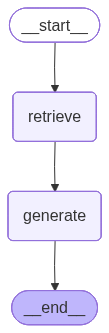

In [24]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(AgentState)

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)

graph = graph_builder.compile()
graph

In [25]:
query

'결혼하면 얼마를 받을 수 있을까?'

In [27]:
initial_state = {'query': query}
result = graph.invoke(initial_state)

In [28]:
result

{'query': '결혼하면 얼마를 받을 수 있을까?',
 'context': [Document(id='16722ed3-da55-4721-8920-06d67467b50a', metadata={'producer': 'Microsoft: Print To PDF', 'creator': '', 'creationdate': '2026-01-16T00:25:28+09:00', 'source': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'file_path': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'total_pages': 22, 'format': 'PDF 1.7', 'title': 'Microsoft Word - Employee_Benefits_Guide_2026_v1.docx', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-01-16T00:25:28+09:00', 'trapped': '', 'modDate': "D:20260116002528+09'00'", 'creationDate': "D:20260116002528+09'00'", 'page': 8}, page_content='가족 수당 \n부양 가족이 있는 자\n배우자 5 만원, \n자녀당 3 만원 / 월 \n등본 제출 필수 \n4.4 특수 영입 및 장기 근속 보너스 (Signing Bonus) \n테크노빌드는 핵심 기술 인력 확보를 위해 입사 시점에 일시불로 지급되는 사이닝 보너스 \n제도를 운영합니다. \nA. 지급 대상 및 금액 \n1. 대상: 연구직 G3 이상 또는 사외 특급 기술 자격 보유자 중 채용위원회 승인을 득한 \n자. \n2. 지급액: 전 직장 연봉의 10% ~ 50% 범위 내에서 개별 협의. \n3. 지급 시기: 입사 첫 달 급여일에 일괄 지급. \nB. 의무 근속 및 환수(Clawback) 조항 \n지급 후 36 개월(3 년) 이내에 개